In [1]:
!pip -q install imbalanced-learn

# Importations de base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Packages de base importés!")

✅ Packages de base importés!


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report)
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Imbalanced-learn
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

print("✅ Tous les packages ML/DL importés!")

✅ Tous les packages ML/DL importés!


In [3]:
# Configuration des URLs
train_url = "https://raw.githubusercontent.com/Jehuty4949/NSL_KDD/master/KDDTrain%2B.csv"
test_url = "https://raw.githubusercontent.com/Jehuty4949/NSL_KDD/master/KDDTest%2B.csv"

# Noms des fichiers locaux
train_path = "KDDTrain+.csv"
test_path = "KDDTest+.csv"

# Téléchargement
print("📥 Téléchargement des données NSL-KDD...")
!wget -q -O "{train_path}" "{train_url}"
!wget -q -O "{test_path}" "{test_url}"

# Vérification
import os
print(f"Train file: {os.path.getsize(train_path)} bytes")
print(f"Test file: {os.path.getsize(test_path)} bytes")
print("✅ Téléchargement terminé!")

📥 Téléchargement des données NSL-KDD...
Train file: 14612857 bytes
Test file: 2639177 bytes
✅ Téléchargement terminé!


In [4]:
# Définition des noms de colonnes NSL-KDD
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

# Chargement des données
print("📊 Chargement des données...")
train_df = pd.read_csv(train_path, header=None, names=col_names)
test_df = pd.read_csv(test_path, header=None, names=col_names)

# Affichage des informations
print("\n📋 Informations sur le dataset:")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print("\n🔍 Aperçu du train:")
print(train_df.head())
print("\n📈 Types de données:")
print(train_df.dtypes.value_counts())

📊 Chargement des données...

📋 Informations sur le dataset:
Train shape: (125973, 43)
Test shape: (22543, 43)

🔍 Aperçu du train:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \


In [5]:
# Analyse des données
print("📊 ANALYSE EXPLORATOIRE")
print("=" * 50)

# 1. Distribution des classes
print("\n1. Distribution des labels:")
print("Train:")
print(train_df['label'].value_counts())
print("\nTest:")
print(test_df['label'].value_counts())

# 2. Types d'attaques
print("\n2. Types d'attaques détaillées:")
attack_types_train = train_df['label'].value_counts()
print(f"Nombre de types d'attaques différents (train): {len(attack_types_train)}")

# 3. Valeurs manquantes
print("\n3. Valeurs manquantes:")
print("Train:")
print(train_df.isnull().sum().sum())
print("Test:")
print(test_df.isnull().sum().sum())

# 4. Statistiques descriptives
print("\n4. Statistiques descriptives (features numériques):")
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
print(train_df[numeric_cols].describe().T.head(10))

📊 ANALYSE EXPLORATOIRE

1. Distribution des labels:
Train:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Test:
label
normal             9710
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetat

In [6]:
# Fonction de binarisation
def to_binary(label_series):
    """Convertit les labels en binaire: normal=0, attack=1"""
    return np.where(label_series == "normal", 0, 1)

# Application
print("🔧 Binarisation des labels...")
y_train = to_binary(train_df["label"])
y_test = to_binary(test_df["label"])

# Séparation features/labels
X_train_raw = train_df.drop(columns=["label", "difficulty"])
X_test_raw = test_df.drop(columns=["label", "difficulty"])

print(f"\n✅ Labels binarisés!")
print(f"X_train shape: {X_train_raw.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_raw.shape}")
print(f"y_test shape: {y_test.shape}")

# Distribution des classes binaires
print("\n📊 Distribution binaire:")
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)
print(f"Train - Normal: {train_counts[0]}, Attack: {train_counts[1]}")
print(f"Test - Normal: {test_counts[0]}, Attack: {test_counts[1]}")

🔧 Binarisation des labels...

✅ Labels binarisés!
X_train shape: (125973, 41)
y_train shape: (125973,)
X_test shape: (22543, 41)
y_test shape: (22543,)

📊 Distribution binaire:
Train - Normal: 67343, Attack: 58630
Test - Normal: 9710, Attack: 12833


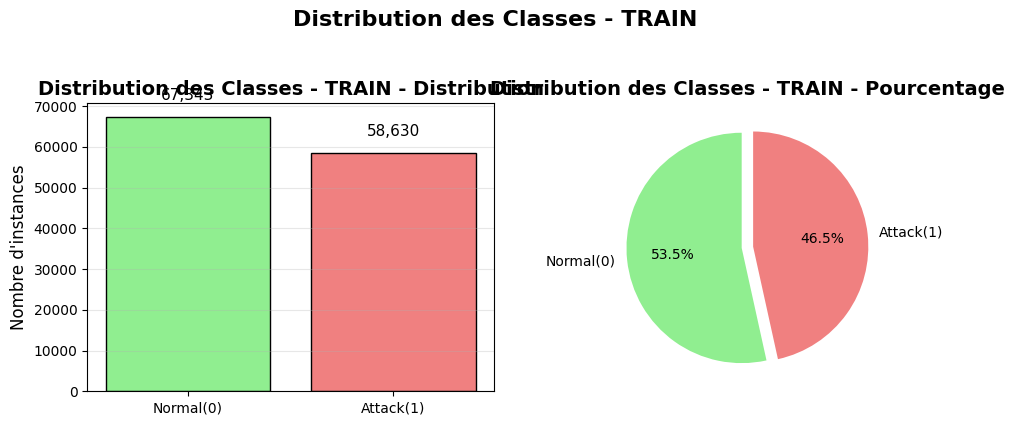

Ratio Attack/Normal: 0.87
Pourcentage d'attaques: 46.54%


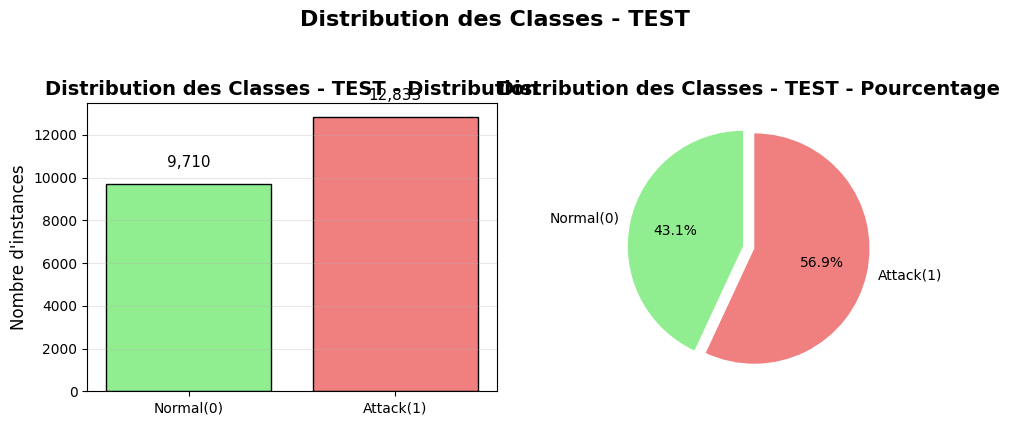

Ratio Attack/Normal: 1.32
Pourcentage d'attaques: 56.93%


In [7]:
# Fonction de visualisation améliorée
def plot_class_distribution(y, title, figsize=(10, 4)):
    """Visualise la distribution des classes"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Bar plot
    values, counts = np.unique(y, return_counts=True)
    labels = ["Normal(0)", "Attack(1)"]
    colors = ['lightgreen', 'lightcoral']

    bars = ax1.bar(labels, counts, color=colors, edgecolor='black')
    ax1.set_title(f"{title} - Distribution", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Nombre d'instances", fontsize=12)
    ax1.grid(axis='y', alpha=0.3)

    # Ajouter les valeurs sur les barres
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05*max(counts),
                f'{count:,}', ha='center', va='bottom', fontsize=11)

    # Pie chart
    explode = (0.05, 0.05)
    ax2.pie(counts, labels=labels, autopct='%1.1f%%',
           colors=colors, explode=explode, startangle=90)
    ax2.set_title(f"{title} - Pourcentage", fontsize=14, fontweight='bold')

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    # Calcul des ratios
    ratio = counts[1] / counts[0] if counts[0] > 0 else np.inf
    print(f"Ratio Attack/Normal: {ratio:.2f}")
    print(f"Pourcentage d'attaques: {(counts[1]/sum(counts))*100:.2f}%")

# Visualisation
plot_class_distribution(y_train, "Distribution des Classes - TRAIN")
plot_class_distribution(y_test, "Distribution des Classes - TEST")

In [8]:
# Identification des colonnes catégorielles et numériques
print("🔧 Préparation du préprocessing...")
cat_cols = ["protocol_type", "service", "flag"]
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

print(f"Colonnes catégorielles ({len(cat_cols)}): {cat_cols}")
print(f"Colonnes numériques ({len(num_cols)}): {num_cols[:5]}...")  # Afficher seulement les 5 premières

# Création du pipeline de préprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols)
    ],
    remainder="passthrough"
)

# Test du préprocessing
print("\n🧪 Test du préprocessing...")
X_sample = preprocess.fit_transform(X_train_raw.head(100))
print(f"Shape après transformation: {X_sample.shape}")
print(f"Nombre de features après encodage: {X_sample.shape[1]}")

print("✅ Pipeline de préprocessing créé!")

🔧 Préparation du préprocessing...
Colonnes catégorielles (3): ['protocol_type', 'service', 'flag']
Colonnes numériques (38): ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment']...

🧪 Test du préprocessing...
Shape après transformation: (100, 68)
Nombre de features après encodage: 68
✅ Pipeline de préprocessing créé!


In [9]:
# Fonction d'évaluation complète
def evaluate_model(model_name, y_true, y_pred, y_proba=None,
                   display_cm=True, display_roc=True):
    """
    Évalue un modèle de classification binaire avec plusieurs métriques
    """
    # Calcul des métriques
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

    if y_proba is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_proba)

    # Affichage des résultats
    print(f"\n{'='*60}")
    print(f"📊 ÉVALUATION DU MODÈLE: {model_name}")
    print(f"{'='*60}")

    for metric, value in metrics.items():
        print(f"{metric:12}: {value:.4f}")

    # Matrice de confusion
    if display_cm:
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=["Normal", "Attack"])

        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, cmap='Blues', values_format='d')
        plt.title(f'Matrice de Confusion - {model_name}', fontweight='bold')
        plt.tight_layout()
        plt.show()

    # Courbe ROC
    if display_roc and y_proba is not None:
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)

        plt.figure(figsize=(7, 6))
        plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {metrics["ROC-AUC"]:.3f}')
        plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
        plt.fill_between(fpr, tpr, alpha=0.2, color='blue')

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=12)
        plt.ylabel('True Positive Rate', fontsize=12)
        plt.title(f'Courbe ROC - {model_name}', fontweight='bold', fontsize=14)
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Rapport de classification détaillé
    print("\n📋 Rapport de classification détaillé:")
    print(classification_report(y_true, y_pred,
                                target_names=["Normal", "Attack"],
                                digits=4))

    return metrics

print("✅ Fonctions d'évaluation définies!")

✅ Fonctions d'évaluation définies!


🌲 MODÈLE 1: RANDOM FOREST (BASELINE)

🔄 Entraînement du modèle...
✅ Entraînement terminé!

🔮 Prédictions sur le test set...

📊 ÉVALUATION DU MODÈLE: Random Forest Baseline
Accuracy    : 0.7787
Precision   : 0.9690
Recall      : 0.6314
F1-Score    : 0.7646
ROC-AUC     : 0.9598


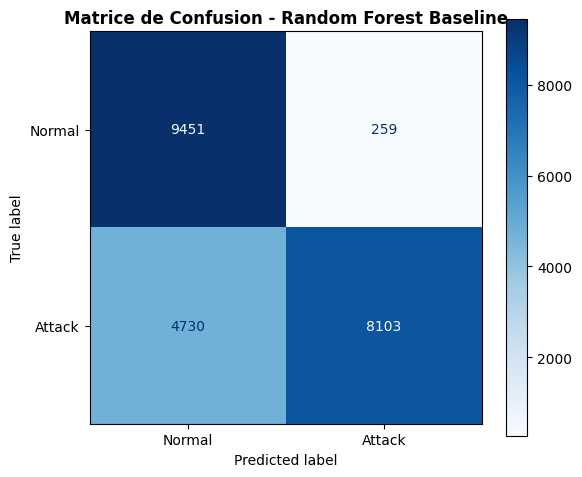

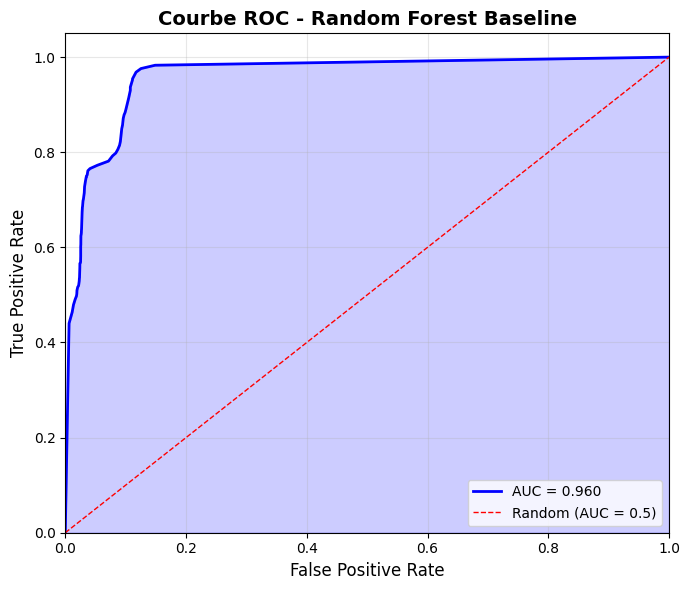


📋 Rapport de classification détaillé:
              precision    recall  f1-score   support

      Normal     0.6665    0.9733    0.7912      9710
      Attack     0.9690    0.6314    0.7646     12833

    accuracy                         0.7787     22543
   macro avg     0.8177    0.8024    0.7779     22543
weighted avg     0.8387    0.7787    0.7761     22543



In [10]:
print("🌲 MODÈLE 1: RANDOM FOREST (BASELINE)")
print("="*50)

# Création du modèle
rf_model = RandomForestClassifier(
    n_estimators=100,        # Nombre d'arbres
    max_depth=None,          # Profondeur maximale
    min_samples_split=2,     # Échantillons minimum pour diviser
    min_samples_leaf=1,      # Échantillons minimum dans feuille
    random_state=42,         # Reproductibilité
    n_jobs=-1,               # Utiliser tous les cœurs
    verbose=0
)

# Pipeline complet
rf_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', rf_model)
])

# Entraînement
print("\n🔄 Entraînement du modèle...")
rf_pipeline.fit(X_train_raw, y_train)
print("✅ Entraînement terminé!")

# Prédiction
print("\n🔮 Prédictions sur le test set...")
rf_preds = rf_pipeline.predict(X_test_raw)
rf_probs = rf_pipeline.predict_proba(X_test_raw)[:, 1]

# Évaluation
rf_metrics = evaluate_model(
    "Random Forest Baseline",
    y_test, rf_preds, rf_probs,
    display_cm=True,
    display_roc=True
)

⚖️ MODÈLE 2: RANDOM FOREST AVEC SMOTE

🔄 Entraînement avec SMOTE...
✅ Entraînement terminé!

🔮 Prédictions sur le test set...

📊 ÉVALUATION DU MODÈLE: Random Forest avec SMOTE
Accuracy    : 0.7772
Precision   : 0.9689
Recall      : 0.6288
F1-Score    : 0.7627
ROC-AUC     : 0.9611


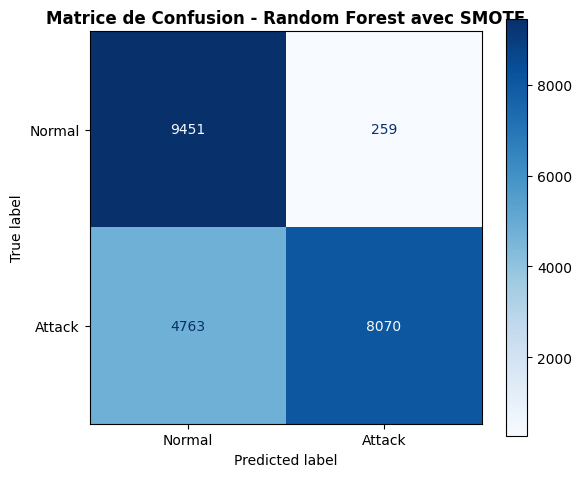

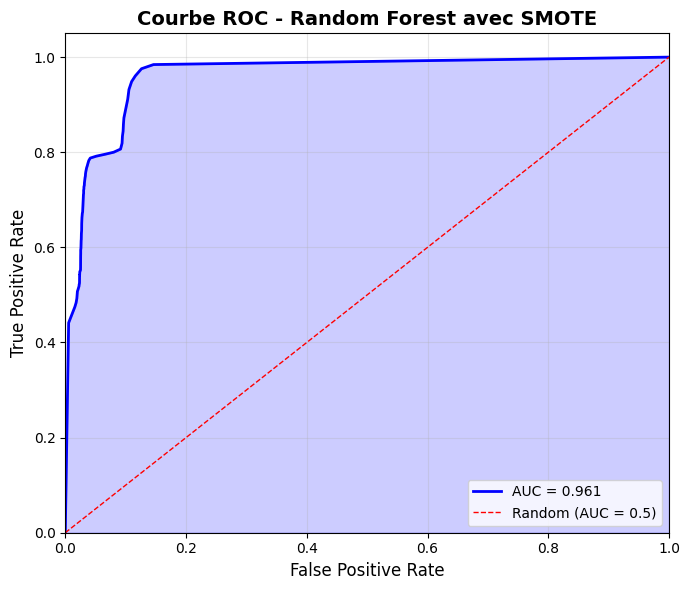


📋 Rapport de classification détaillé:
              precision    recall  f1-score   support

      Normal     0.6649    0.9733    0.7901      9710
      Attack     0.9689    0.6288    0.7627     12833

    accuracy                         0.7772     22543
   macro avg     0.8169    0.8011    0.7764     22543
weighted avg     0.8380    0.7772    0.7745     22543



In [11]:
print("⚖️ MODÈLE 2: RANDOM FOREST AVEC SMOTE")
print("="*50)

# Modèle avec pipeline SMOTE
rf_smote_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Pipeline avec SMOTE
rf_smote_pipeline = ImbPipeline([
    ('preprocessor', preprocess),
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('classifier', rf_smote_model)
])

# Entraînement
print("\n🔄 Entraînement avec SMOTE...")
rf_smote_pipeline.fit(X_train_raw, y_train)
print("✅ Entraînement terminé!")

# Prédiction
print("\n🔮 Prédictions sur le test set...")
rf_smote_preds = rf_smote_pipeline.predict(X_test_raw)
rf_smote_probs = rf_smote_pipeline.predict_proba(X_test_raw)[:, 1]

# Évaluation
rf_smote_metrics = evaluate_model(
    "Random Forest avec SMOTE",
    y_test, rf_smote_preds, rf_smote_probs,
    display_cm=True,
    display_roc=True
)

📊 COMPARAISON DES MODÈLES RANDOM FOREST

📈 Tableau comparatif des métriques:
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
RandomForest Baseline    0.7787     0.9690  0.6314    0.7646   0.9598
RandomForest + SMOTE     0.7772     0.9689  0.6288    0.7627   0.9611


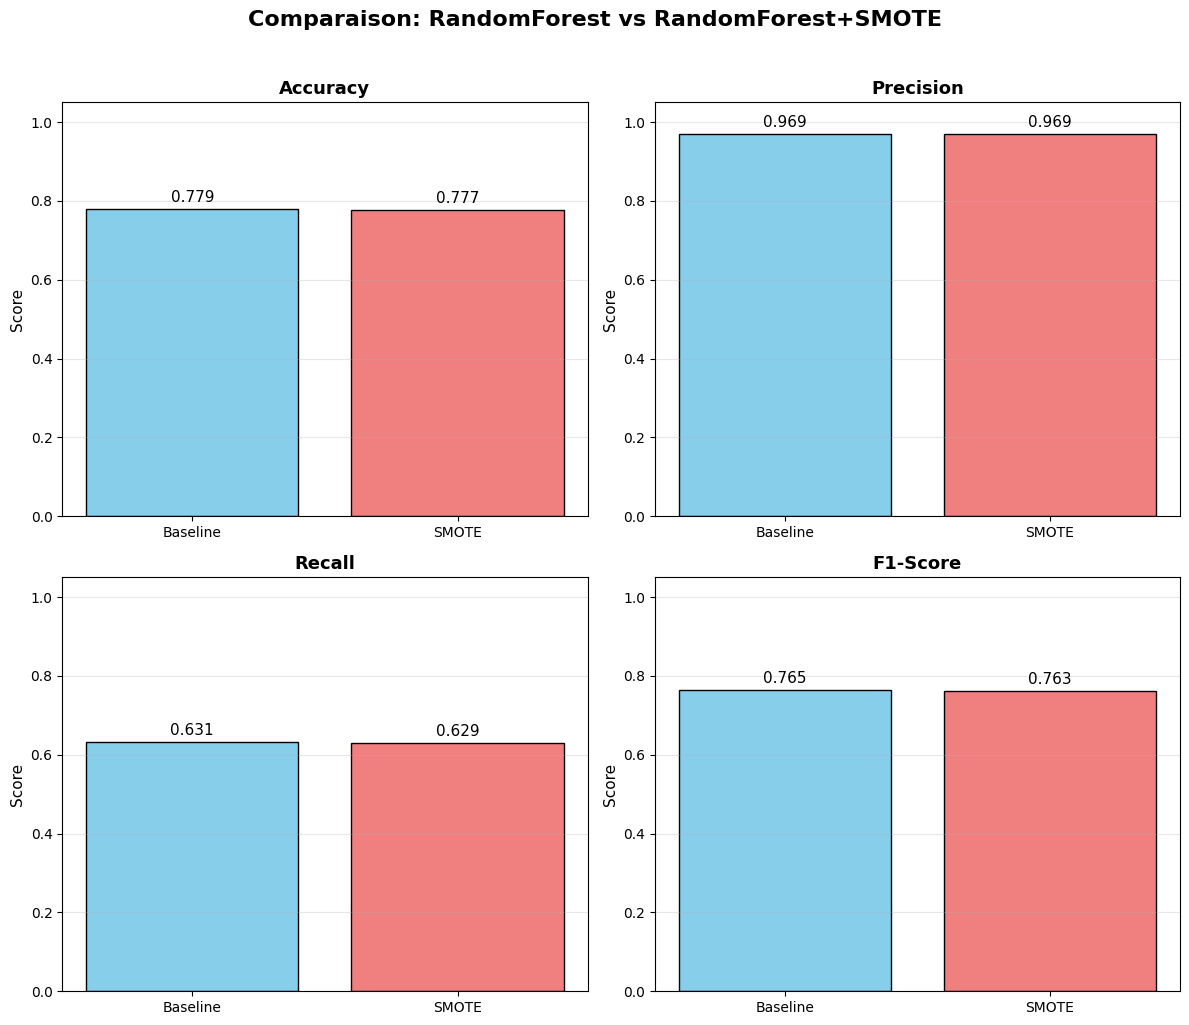


💡 CONCLUSION:
⚠️  Accuracy: -0.001 avec SMOTE
⚠️  Precision: -0.000 avec SMOTE
⚠️  Recall: -0.003 avec SMOTE
⚠️  F1-Score: -0.002 avec SMOTE


In [12]:
print("📊 COMPARAISON DES MODÈLES RANDOM FOREST")
print("="*50)

# Création d'un DataFrame de comparaison
comparison_df = pd.DataFrame({
    'RandomForest Baseline': rf_metrics,
    'RandomForest + SMOTE': rf_smote_metrics
}).T

# Affichage
print("\n📈 Tableau comparatif des métriques:")
print(comparison_df.round(4))

# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx//2, idx%2]

    # Valeurs
    baseline_val = rf_metrics.get(metric, 0)
    smote_val = rf_smote_metrics.get(metric, 0)

    # Bar plot
    bars = ax.bar(['Baseline', 'SMOTE'], [baseline_val, smote_val],
                 color=['skyblue', 'lightcoral'], edgecolor='black')

    ax.set_title(f'{metric}', fontweight='bold', fontsize=13)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

    # Ajouter les valeurs
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Comparaison: RandomForest vs RandomForest+SMOTE',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Conclusion
print("\n💡 CONCLUSION:")
improvements = {}
for metric in metrics_to_plot:
    base = rf_metrics.get(metric, 0)
    smote = rf_smote_metrics.get(metric, 0)
    improvement = smote - base
    improvements[metric] = improvement

    if improvement > 0:
        print(f"✅ {metric}: +{improvement:.3f} avec SMOTE")
    elif improvement < 0:
        print(f"⚠️  {metric}: {improvement:.3f} avec SMOTE")
    else:
        print(f"➖ {metric}: Pas de changement")

In [13]:
print("🧠 PRÉPARATION POUR DEEP LEARNING")
print("="*50)

# 1. Préprocessing des données
print("\n1. Préprocessing des données...")
X_train_processed = preprocess.fit_transform(X_train_raw)
X_test_processed = preprocess.transform(X_test_raw)

print(f"✅ Données transformées!")
print(f"X_train shape: {X_train_processed.shape}")
print(f"X_test shape: {X_test_processed.shape}")

# 2. Normalisation supplémentaire (optionnel)
from sklearn.preprocessing import MinMaxScaler

# Si besoin de normaliser entre 0 et 1
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print(f"\n2. Normalisation MinMax appliquée")
print(f"Plage des données: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")

# 3. Split validation set
print("\n3. Création du validation set...")
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f"Train final: {X_train_final.shape}")
print(f"Validation: {X_val_final.shape}")
print(f"Test: {X_test_scaled.shape}")

# 4. Application de SMOTE pour DL (optionnel)
print("\n4. Application de SMOTE (optionnel pour DL)...")
smote_dl = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote_dl.fit_resample(X_train_final, y_train_final)

print(f"Avant SMOTE: {X_train_final.shape}, {y_train_final.shape}")
print(f"Après SMOTE: {X_train_smote.shape}, {y_train_smote.shape}")

# 5. Création des datasets TensorFlow
print("\n5. Création des datasets TensorFlow...")
batch_size = 64

# Dataset avec SMOTE
train_dataset_smote = tf.data.Dataset.from_tensor_slices(
    (X_train_smote, y_train_smote)
).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Dataset sans SMOTE
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_final, y_train_final)
).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val_final, y_val_final)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Test dataset
test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test_scaled, y_test)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("✅ Datasets TensorFlow créés!")
print(f"Batch size: {batch_size}")

🧠 PRÉPARATION POUR DEEP LEARNING

1. Préprocessing des données...
✅ Données transformées!
X_train shape: (125973, 122)
X_test shape: (22543, 122)

2. Normalisation MinMax appliquée
Plage des données: [0.00, 1.00]

3. Création du validation set...
Train final: (100778, 122)
Validation: (25195, 122)
Test: (22543, 122)

4. Application de SMOTE (optionnel pour DL)...
Avant SMOTE: (100778, 122), (100778,)
Après SMOTE: (107748, 122), (107748,)

5. Création des datasets TensorFlow...
✅ Datasets TensorFlow créés!
Batch size: 64


In [14]:
print("🧠 MODÈLE 3: DEEP LEARNING (BASELINE)")
print("="*50)

# Configuration
input_shape = X_train_final.shape[1]
print(f"Input shape: {input_shape}")

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Construction du modèle
print("\n🏗️  Construction du modèle DL...")
dl_model = keras.Sequential([
    # Couche d'entrée
    layers.Input(shape=(input_shape,)),

    # Couches cachées
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Couche de sortie
    layers.Dense(1, activation='sigmoid')
])

# Compilation
dl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("\n📋 Architecture du modèle:")
dl_model.summary()

# Entraînement
print("\n🔄 Entraînement du modèle...")
history = dl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("✅ Entraînement terminé!")

🧠 MODÈLE 3: DEEP LEARNING (BASELINE)
Input shape: 122

🏗️  Construction du modèle DL...

📋 Architecture du modèle:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 73,601 (287.50 KB)

 Non-trainable params: 896 (3.50 KB)


🔄 Entraînement du modèle...
Epoch 1/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9696 - auc: 0.9919 - loss: 0.0868 - precision: 0.9744 - recall: 0.9599 - val_accuracy: 0.9885 - val_auc: 0.9994 - val_loss: 0.0296 - val_precision: 0.9940 - val_recall: 0.9812 - learning_rate: 0.0010
Epoch 2/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9861 - auc: 0.9986 - loss: 0.0387 - precision: 0.9883 - recall: 0.9818 - val_accuracy: 0.9919 - val_auc: 0.9995 - val_loss: 0.0238 - val_precision: 0.9921 - val_recall: 0.9906 - learning_rate: 0.0010
Epoch 3/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9889 - auc: 0.9989 - loss: 0.0310 - precision: 0.9899 - recall: 0.9862 - val_accuracy: 0.9913 - val_auc: 0.9996 - val_loss: 0.0224 - val_precision: 0.9922 - val_recall: 0.9892 - learning_rate: 0.0010
Epoch 4/50
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9909 - auc: 0.9993 - loss: 0.0257 - precision: 0.9910 - recall: 0.9893 - val_accuracy: 0.9934 -

📊 ÉVALUATION DU MODÈLE DEEP LEARNING


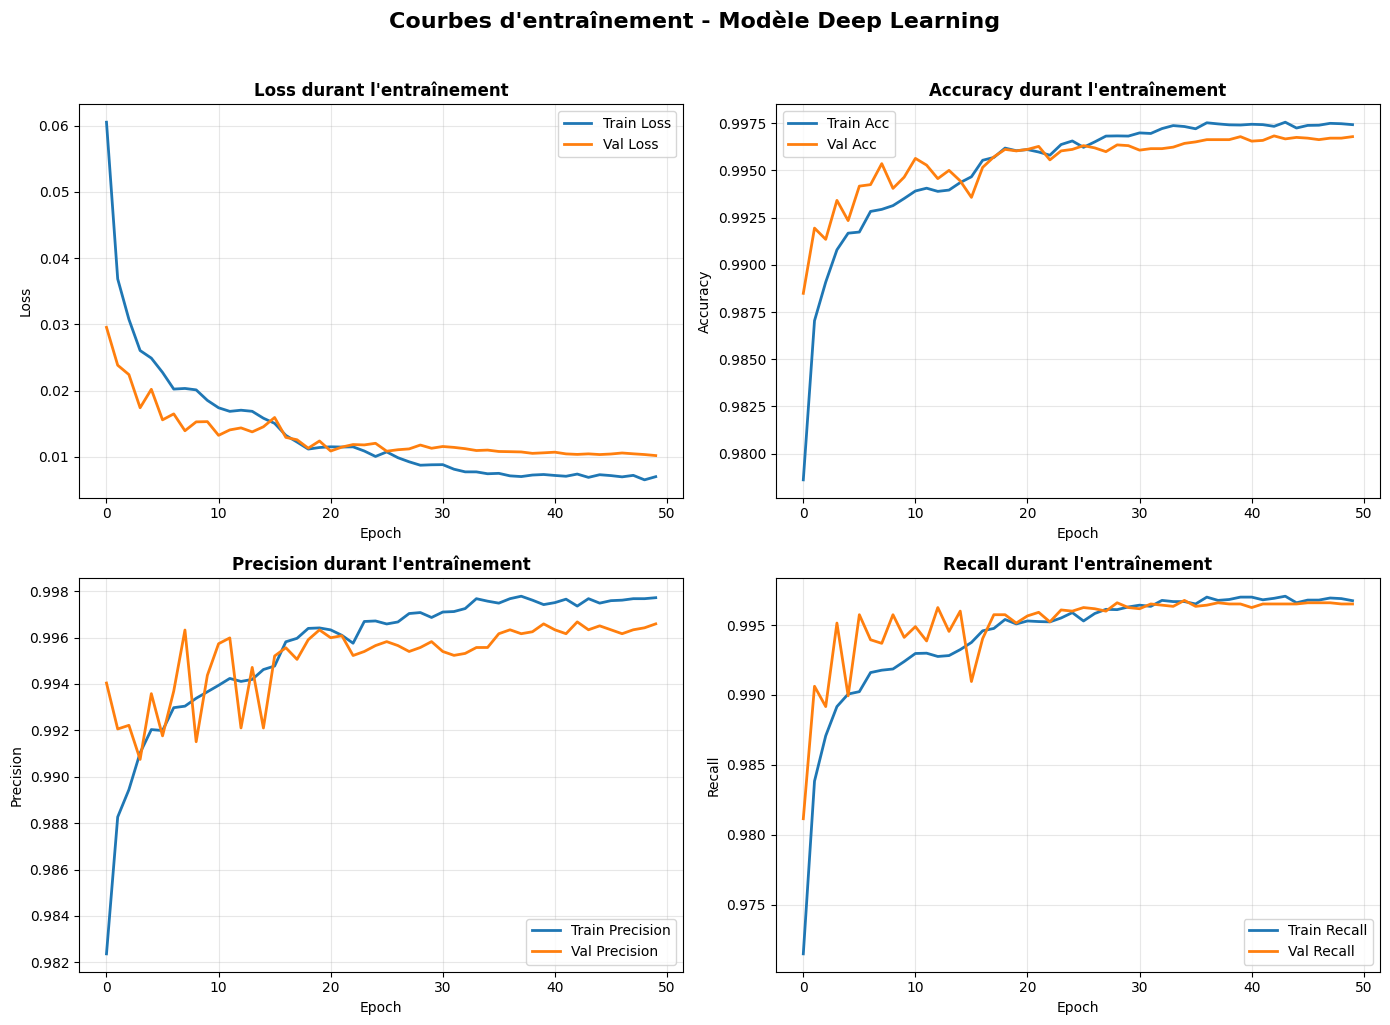


🔮 Évaluation sur le test set...

📊 Résultats sur le test set:
Test Loss:     2.4324
Test Accuracy: 0.7945
Test Precision:0.9264
Test Recall:   0.6941
Test AUC:      0.8418

🔮 Génération des prédictions...

📊 ÉVALUATION DU MODÈLE: Deep Learning Baseline
Accuracy    : 0.7945
Precision   : 0.9264
Recall      : 0.6941
F1-Score    : 0.7936
ROC-AUC     : 0.8436


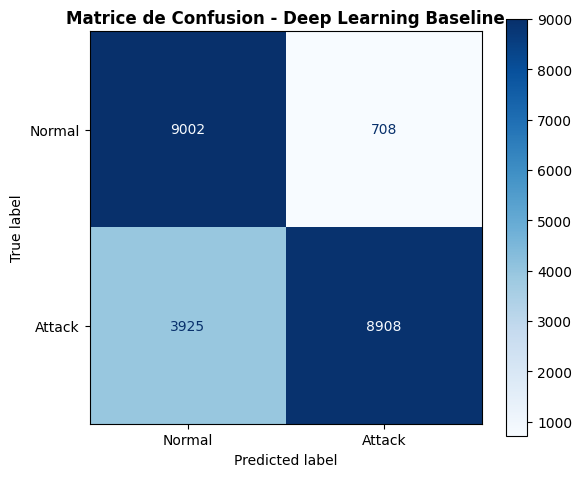

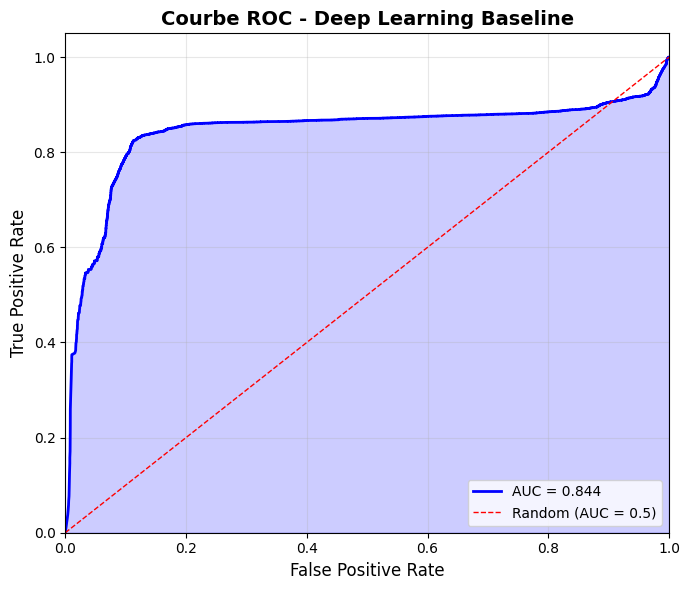


📋 Rapport de classification détaillé:
              precision    recall  f1-score   support

      Normal     0.6964    0.9271    0.7953      9710
      Attack     0.9264    0.6941    0.7936     12833

    accuracy                         0.7945     22543
   macro avg     0.8114    0.8106    0.7945     22543
weighted avg     0.8273    0.7945    0.7944     22543



In [15]:
print("📊 ÉVALUATION DU MODÈLE DEEP LEARNING")
print("="*50)

# 1. Visualisation de l'entraînement
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Loss durant l\'entraînement', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Acc', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[0, 1].set_title('Accuracy durant l\'entraînement', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
axes[1, 0].set_title('Precision durant l\'entraînement', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
axes[1, 1].set_title('Recall durant l\'entraînement', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Courbes d\'entraînement - Modèle Deep Learning',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. Évaluation sur le test set
print("\n🔮 Évaluation sur le test set...")
test_results = dl_model.evaluate(test_dataset, verbose=0)
test_loss, test_acc, test_precision, test_recall, test_auc = test_results

print(f"\n📊 Résultats sur le test set:")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision:{test_precision:.4f}")
print(f"Test Recall:   {test_recall:.4f}")
print(f"Test AUC:      {test_auc:.4f}")

# 3. Prédictions
print("\n🔮 Génération des prédictions...")
dl_probs = dl_model.predict(test_dataset, verbose=0).flatten()
dl_preds = (dl_probs > 0.5).astype(int)

# 4. Métriques détaillées
dl_metrics = evaluate_model(
    "Deep Learning Baseline",
    y_test, dl_preds, dl_probs,
    display_cm=True,
    display_roc=True
)

In [16]:
print("⚖️ MODÈLE 4: DEEP LEARNING AVEC SMOTE")
print("="*50)

# Construction du modèle (identique architecture)
print("\n🏗️  Construction du modèle DL avec SMOTE...")
dl_smote_model = keras.Sequential([
    layers.Input(shape=(input_shape,)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

# Compilation
dl_smote_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

# Entraînement avec données SMOTE
print("\n🔄 Entraînement avec données SMOTE...")
history_smote = dl_smote_model.fit(
    train_dataset_smote,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("✅ Entraînement terminé!")

⚖️ MODÈLE 4: DEEP LEARNING AVEC SMOTE

🏗️  Construction du modèle DL avec SMOTE...

🔄 Entraînement avec données SMOTE...
Epoch 1/50
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9696 - auc: 0.9923 - loss: 0.0868 - precision: 0.9733 - recall: 0.9616 - val_accuracy: 0.9804 - val_auc: 0.9993 - val_loss: 0.0472 - val_precision: 0.9631 - val_recall: 0.9962 - learning_rate: 0.0010
Epoch 2/50
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9817 - auc: 0.9980 - loss: 0.0483 - precision: 0.9791 - recall: 0.9822 - val_accuracy: 0.9825 - val_auc: 0.9994 - val_loss: 0.0468 - val_precision: 0.9655 - val_recall: 0.9980 - learning_rate: 0.0010
Epoch 3/50
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9862 - auc: 0.9986 - loss: 0.0378 - precision: 0.9842 - recall: 0.9865 - val_accuracy: 0.9898 - val_auc: 0.9996 - val_loss: 0.0257 - val_precision: 0.9812 - val_recall: 0.9972 - learning_rate: 0.0010
Epoch 4/50
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.987

🏆 COMPARAISON FINALE DES MODÈLES

🔮 Évaluation DL+SMOTE...

📊 ÉVALUATION DU MODÈLE: Deep Learning avec SMOTE
Accuracy    : 0.7772
Precision   : 0.9252
Recall      : 0.6621
F1-Score    : 0.7719
ROC-AUC     : 0.8859

📋 Rapport de classification détaillé:
              precision    recall  f1-score   support

      Normal     0.6754    0.9292    0.7823      9710
      Attack     0.9252    0.6621    0.7719     12833

    accuracy                         0.7772     22543
   macro avg     0.8003    0.7957    0.7771     22543
weighted avg     0.8176    0.7772    0.7763     22543


📊 TABLEAU COMPARATIF COMPLET:
                        Accuracy  Precision  Recall  F1-Score  ROC-AUC
RandomForest Baseline     0.7787     0.9690  0.6314    0.7646   0.9598
RandomForest + SMOTE      0.7772     0.9689  0.6288    0.7627   0.9611
Deep Learning Baseline    0.7945     0.9264  0.6941    0.7936   0.8436
Deep Learning + SMOTE     0.7772     0.9252  0.6621    0.7719   0.8859


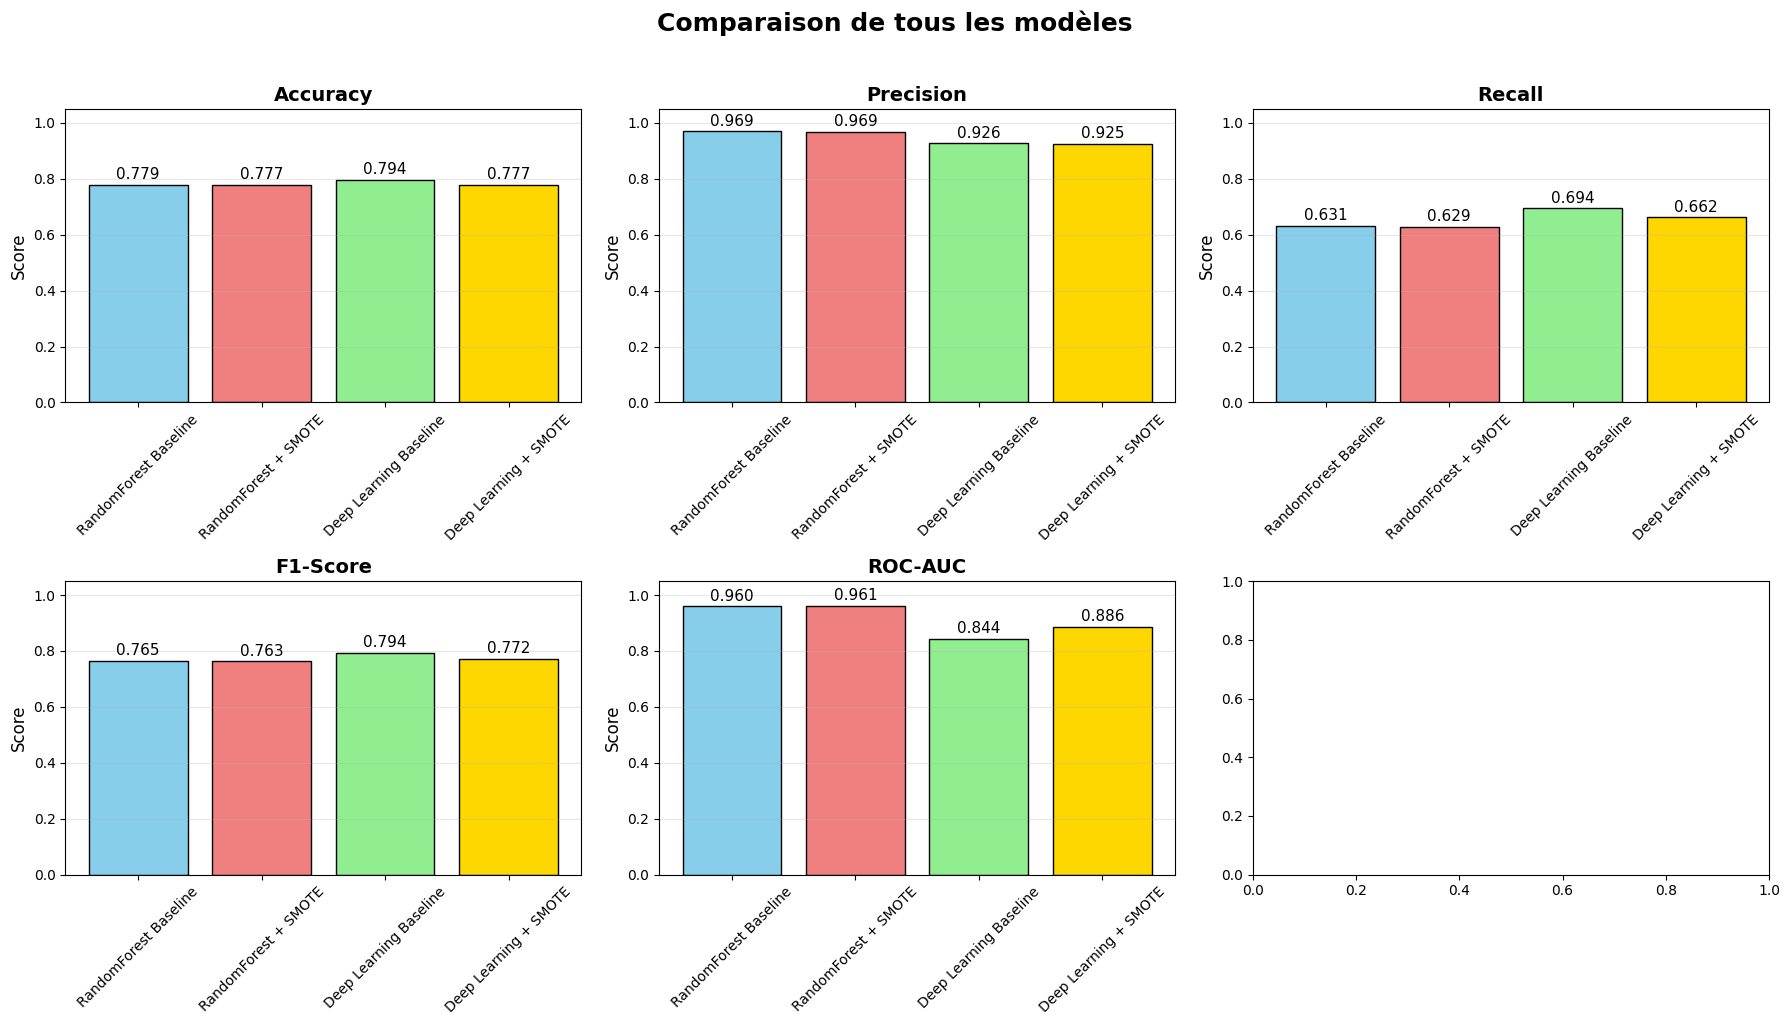


💡 RECOMMANDATIONS:

🎯 Meilleurs modèles par métrique:
  Accuracy    : Deep Learning Baseline (0.7945)
  Precision   : RandomForest Baseline (0.9690)
  Recall      : Deep Learning Baseline (0.6941)
  F1-Score    : Deep Learning Baseline (0.7936)
  ROC-AUC     : RandomForest + SMOTE (0.9611)

🏆 MEILLEUR MODÈLE GLOBAL: RandomForest Baseline
   Score moyen: 0.8207


In [17]:
print("🏆 COMPARAISON FINALE DES MODÈLES")
print("="*60)

# Collecte des métriques
models_comparison = pd.DataFrame({
    'RandomForest Baseline': rf_metrics,
    'RandomForest + SMOTE': rf_smote_metrics,
    'Deep Learning Baseline': dl_metrics,
    'Deep Learning + SMOTE': {}  # À remplir
})

# Remplir les métriques DL+SMOTE
print("\n🔮 Évaluation DL+SMOTE...")
dl_smote_probs = dl_smote_model.predict(test_dataset, verbose=0).flatten()
dl_smote_preds = (dl_smote_probs > 0.5).astype(int)

dl_smote_metrics = evaluate_model(
    "Deep Learning avec SMOTE",
    y_test, dl_smote_preds, dl_smote_probs,
    display_cm=False,
    display_roc=False
)

# Mise à jour de la comparaison
models_comparison['Deep Learning + SMOTE'] = dl_smote_metrics

# Affichage
print("\n📊 TABLEAU COMPARATIF COMPLET:")
print("="*60)
print(models_comparison.T.round(4))

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for idx, metric in enumerate(metrics_list):
    ax = axes[idx//3, idx%3]

    models = models_comparison.columns
    values = [models_comparison.loc[metric, model] for model in models]
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

    bars = ax.bar(models, values, color=colors, edgecolor='black')
    ax.set_title(f'{metric}', fontweight='bold', fontsize=14)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

    # Ajouter les valeurs
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Comparaison de tous les modèles',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Recommandation finale
print("\n💡 RECOMMANDATIONS:")
print("="*60)

# Trouver le meilleur modèle pour chaque métrique
best_models = {}
for metric in metrics_list:
    if metric in models_comparison.index:
        best_idx = models_comparison.loc[metric].astype(float).idxmax()
        best_models[metric] = (best_idx, models_comparison.loc[metric, best_idx])

print("\n🎯 Meilleurs modèles par métrique:")
for metric, (model, score) in best_models.items():
    print(f"  {metric:12}: {model} ({score:.4f})")

# Modèle global (moyenne des scores)
if 'ROC-AUC' in models_comparison.index:
    avg_scores = {}
    for model in models_comparison.columns:
        scores = []
        for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
            if metric in models_comparison.index:
                scores.append(models_comparison.loc[metric, model])
        avg_scores[model] = np.mean(scores) if scores else 0

    best_overall = max(avg_scores, key=avg_scores.get)
    print(f"\n🏆 MEILLEUR MODÈLE GLOBAL: {best_overall}")
    print(f"   Score moyen: {avg_scores[best_overall]:.4f}")